# 하수 수위 예측 GNN — Phase 0: 베이스라인

**목표**: 관악 GIS 범위 하수센서 17개의 **수위 nowcast**(t+10/30/60분). 라벨 불필요(연속 수위가 타깃).
**이 노트북의 역할**: GNN이 반드시 이겨야 할 **바(bar)** 설정 — ① persistence(직전값 유지) ② 강우+자기이력 회귀(그래프 없음).
GNN(관망 엣지)이 이 둘을 못 이기면 토폴로지는 무의미.

**평가**: 시간분할(train ~2025-04 / test 2025-05~08 여름), MAE·RMSE(수위 m), 고수위 구간 조건부 오차.

In [1]:
import os; os.chdir("/home/namjun/city_flood")   # 루트 기준 실행 부트스트랩
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from sklearn.ensemble import HistGradientBoostingRegressor
mpl.rcParams['font.family']=['DejaVu Sans']
EB="dataset/processed/eda_based/"
ids=pd.read_csv("03_GIS/derived/gwanak_sewer_nodes.csv").sewer_id.astype(str).tolist()
HZ=[1,3,6]   # 10/30/60분 (10분 bin)
print("센서",len(ids),"| 호라이즌(bin)",HZ)

센서 17 | 호라이즌(bin) [1, 3, 6]


## 1. 데이터 조립 — 수위 + AWS 강우

In [2]:
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",
    columns=['sewer_sensor_id','ts10','level_max_10m'],
    filters=[('sewer_sensor_id','in',ids)]).rename(columns={'sewer_sensor_id':'sid','level_max_10m':'lvl'})
m=pd.read_parquet(EB+"aws_sewer_mapping_v2.parquet")[['sensor_id','aws_stn']]
r=pd.read_parquet("data/aws_seoul_rain_10min.parquet",columns=['stn','ts10','rn60m']).sort_values(['stn','ts10'])
r['rain6h']=r.groupby('stn')['rn60m'].transform(lambda s:s.fillna(0).rolling(36,min_periods=1).max())
sf=sf.merge(m,left_on='sid',right_on='sensor_id',how='left').merge(
    r,left_on=['aws_stn','ts10'],right_on=['stn','ts10'],how='left')
sf=sf[sf.rn60m.notna()].sort_values(['sid','ts10'])   # AWS 강우 커버 구간만
print("조립 후:",sf.shape,"| 기간",sf.ts10.min(),"~",sf.ts10.max())

조립 후: (236553, 8) | 기간 2024-06-01 00:00:00 ~ 2025-08-31 23:50:00


## 2. 지도학습 프레임 — 누수 없는 피처(시각 t에 알 수 있는 것만)

In [3]:
def build(d):
    d=d.sort_values('ts10').copy()
    d['lvl_l1']=d.lvl.shift(1); d['lvl_l3']=d.lvl.shift(3)
    d['trend']=d.lvl-d.lvl_l1
    d['rain_now']=d.rn60m.fillna(0); d['rain6h']=d.rain6h.fillna(0)
    d['hour']=d.ts10.dt.hour; d['month']=d.ts10.dt.month
    for h in HZ: d[f'y{h}']=d.lvl.shift(-h)
    return d
F=sf.groupby('sid',group_keys=False).apply(build).dropna(subset=['lvl_l3'])
feat=['lvl','lvl_l1','lvl_l3','trend','rain_now','rain6h','hour','month']
# 시간분할
cut=pd.Timestamp('2025-05-01')
tr=F[F.ts10<cut]; te=F[F.ts10>=cut]
print(f"train {len(tr)} (~{cut.date()}) | test {len(te)} (2025-05~)")

train 165007 (~2025-05-01) | test 71495 (2025-05~)


## 3. 베이스라인 학습·평가

In [4]:
def metrics(y,p):
    e=p-y; return dict(MAE=np.abs(e).mean(), RMSE=np.sqrt((e**2).mean()))
rows=[]
for h in HZ:
    yte=te[f'y{h}'].values; m_te=te[f'y{h}'].notna()
    # A. persistence
    pA=te['lvl'].values
    # B. 강우+이력 회귀(pooled HGB, 센서 무관 피처)
    mtr=tr[f'y{h}'].notna()
    gb=HistGradientBoostingRegressor(max_iter=300,max_depth=6,learning_rate=0.05,random_state=0)
    gb.fit(tr.loc[mtr,feat], tr.loc[mtr,f'y{h}'])
    pB=gb.predict(te[feat])
    for name,p in [('persistence',pA),('rain+history GBM',pB)]:
        mm=metrics(yte[m_te],p[m_te]); rows.append([h*10,name,mm['MAE'],mm['RMSE']])
R=pd.DataFrame(rows,columns=['horizon(min)','model','MAE','RMSE'])
print(R.pivot(index='horizon(min)',columns='model',values=['MAE','RMSE']).round(4).to_string())
R.to_parquet(EB+"gnn_baseline_metrics.parquet",index=False)

                     MAE                         RMSE                 
model        persistence rain+history GBM persistence rain+history GBM
horizon(min)                                                          
10                0.0075           0.0084      0.0371           0.0355
30                0.0174           0.0202      0.0699           0.0665
60                0.0240           0.0259      0.0892           0.0812


## 4. 고수위 구간 조건부 — 비 올 때(진짜 어려운 구간)

In [5]:
hi=te[te.rain6h>0]
print(f"비구간 test 샘플: {len(hi)} ({len(hi)/len(te):.0%})")
for h in HZ:
    mm=hi[f'y{h}'].notna()
    pers=np.abs(hi.loc[mm,'lvl']-hi.loc[mm,f'y{h}']).mean()
    print(f"  +{h*10}분 persistence MAE(비구간): {pers:.4f} m")

비구간 test 샘플: 37625 (53%)
  +10분 persistence MAE(비구간): 0.0125 m
  +30분 persistence MAE(비구간): 0.0281 m
  +60분 persistence MAE(비구간): 0.0369 m


## 5. 시각화 — 호라이즌별 MAE: persistence vs 회귀

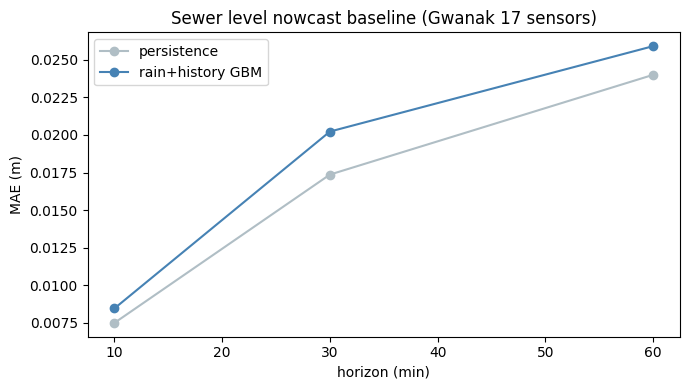

saved reports/figures_gnn/01_baseline.png


In [6]:
fig,ax=plt.subplots(figsize=(7,4))
for name,c in [('persistence','#b0bec5'),('rain+history GBM','steelblue')]:
    s=R[R.model==name]; ax.plot(s['horizon(min)'],s.MAE,'o-',c=c,label=name)
ax.set_xlabel('horizon (min)'); ax.set_ylabel('MAE (m)'); ax.set_title('Sewer level nowcast baseline (Gwanak 17 sensors)')
ax.legend(); plt.tight_layout()
import os; os.makedirs('reports/figures_gnn',exist_ok=True)
plt.savefig('reports/figures_gnn/01_baseline.png',dpi=110,bbox_inches='tight'); plt.show()
print('saved reports/figures_gnn/01_baseline.png')

## 결론 (Phase 0)
- 이 표가 **GNN이 이겨야 할 바**다. persistence MAE 대비 강우+이력 회귀가 얼마나 줄이는지가 1차 기준.
- 다음(Phase 1): 관악 GIS 관망으로 **유향 그래프** 구성 → 상류 센서 상태·관망 전파를 추가해 이 바를 넘는지 측정.